# Rice growth stages — Sentinel-2 NDVI (formula-based)
Same workflow as the planting-method notebook, with the CNN-LSTM replaced by threshold + derivative phenology:

`S2 L2A (MPC) → SCL cloud mask → 10-day NDVI composites → WorldCover cropland mask → SG smoothing → 15 % amplitude threshold → cycle boundaries → NDVI derivatives/peaks → growth stages`

Outputs per province (GCS COGs):
* `{label}_{PROV}_phenology.tiff`: 15 int16 bands. The 8 transition dates (DOY relative to Jan 1 of `YEAR`), season length, NDVI min/max/NDVI₁₅ (×10000), QC, number of clear observations, and longest gap.
* `{label}_{PROV}_stage_{date}.tiff`: growth-stage class map on each date in `AS_OF_DATES`. It is derived from the date bands, so you can add dates later without reprocessing.

In [ ]:
!pip install -q pystac-client odc-stac planetary-computer \
    xarray rioxarray scipy geopandas matplotlib google-cloud-storage

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 612.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.6/159.6 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.1 MB/s eta 0:00:00


## Import Libraries

In [ ]:
import os, gc, sys, time, logging, warnings, traceback
import numpy as np
import pandas as pd
import geopandas as gpd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=RuntimeWarning)
logging.getLogger('urllib3.connectionpool').setLevel(logging.ERROR)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
sys.path.insert(0, '/content/drive/MyDrive/AGRI/Crop_Growth/notebooks/apps')   # folder with the two .py files
import data_processing as dp
import phenology as ph

# ---- pipeline config ----
TILE_DEG = 0.1                 # S2 is read eagerly per tile; 0.1 deg ≈ 1000x1000 px (0.25 deg can OOM)
YEAR     = 2025
PLANTING_MONTH_FALLBACK = 12   # used if a province row has no planting month
DATE_MEDIAN_RADIUS = 1         # 3x3 spatial smoothing of the stage dates (despeckle); 0 to disable
STAGE_MAJORITY_RADIUS = 0      # optional extra mode filter on each monthly map

# ---- which monthly maps to generate ----
# None -> every month of each province's season window (planting month -1 .. +6)
# or a list, e.g. ['2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
MONTHS = None
STAGE_METHOD = 'dominant'      # 'dominant' = stage occupying most days of the month; 'midmonth' = stage on the 15th
SAVE_PHENOLOGY_BANDS = False   # True -> also save the multi-band QA file with the transition dates

# Phenology parameters (see phenology.DEFAULTS for all of them)
PHENO_CFG = dict(
    THRESHOLD_FRAC=0.15,        # NDVI_15 = min + 0.15 A
    BASE_MODE='separate',       # 'single' = one NDVI_min for the whole cycle
    SG_WINDOW=5, SG_POLYORDER=2,
    MIN_AMPLITUDE=0.20, MIN_PEAK_NDVI=0.50, MAX_BASE_NDVI=0.45,
)
dp.INTERVAL_DAYS = 10
dp.COMPOSITE_METHOD = 'max'

# ---- GCS output ----
GCS_BUCKET = 'leads-agri'
GCS_PREFIX = 'products/growth_stage/2026/dry'
COG_LABEL  = 'dry2026'
TILE_CACHE_DIR = f'/content/drive/MyDrive/AGRI/Crop_Growth/tile_cache/{COG_LABEL}'   # per-tile resume cache

VECTOR_PATH = '/content/drive/MyDrive/AGRI/Crop_Growth/vector/boundary_province_philippines.gpkg'
PROV_COL, PLANT_MO_COL = 'Pro_Name', 'Semester_1'
print('window example:', dp.season_window(PLANTING_MONTH_FALLBACK, YEAR),
      '| GCS ->', f'gs://{GCS_BUCKET}/{GCS_PREFIX}')

window example: ('2025-11-01', '2026-06-30') | GCS -> gs://leads-agri/products/growth_stage/2026/dry


In [ ]:
!gcloud auth application-default login manager@leadsagri.app

Go to the following link in your browser, and complete the sign-in prompts:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=https%3A%2F%2Fsdk.cloud.google.com%2Fapplicationdefaultauthcode.html&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=gdOe7mnMjgcjcvhGwS0H9TFiV7KV0O&prompt=consent&token_usage=remote&access_type=offline&code_challenge=bbqhDILGx70JED23s3ZA71AOQuTdyjisbB-M0LQ2NjE&code_challenge_method=S256

Once finished, enter the verification code provided in your browser: 4/0AXlqoi5mRud1dEOzBML0QwqPO1miaJAFbGQKgFoWXmwCB1oZO7YRr6TM8o6Qvz77PTqEog

Credentials saved to file: [/content/.config/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).
Ca

In [ ]:
!gcloud auth list


No credentialed accounts.

To login, run:
  $ gcloud auth login `ACCOUNT`



In [ ]:
import google.auth
import google.auth.transport.requests

from google.cloud import storage
from google.auth import impersonated_credentials

source_credentials, _ = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

target_credentials = impersonated_credentials.Credentials(
    source_credentials=source_credentials,
    target_principal="leadsagri-ai@sensesaka2024.iam.gserviceaccount.com",
    target_scopes=[
        "https://www.googleapis.com/auth/devstorage.read_write"
    ],
    lifetime=3600,
)

target_credentials.refresh(
    google.auth.transport.requests.Request()
)

print("✓ Impersonation successful")

/usr/local/lib/python3.13/dist-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


✓ Impersonation successful


In [ ]:
gcs_client = storage.Client(
    project="sensesaka2024",
    credentials=target_credentials
)

print("✓ GCS client created")

✓ GCS client created


## Load Province

In [ ]:
gdf = gpd.read_file(VECTOR_PATH).to_crs(4326)
gdf = gdf[~gdf[PROV_COL].astype(str).str.strip().str.upper()
             .str.contains('PALAWAN', na=False)].copy()
gdf[PROV_COL] = gdf[PROV_COL].str.strip().str.upper()
provinces = sorted(gdf[PROV_COL].dropna().unique().tolist())
print(f'{len(provinces)} provinces')

83 provinces


## Quick check on a small area (run this before the batch)
Plots NDVI, the SG curve, NDVI₁₅ and the detected stage dates for a few pixels. This is the place to tune `PHENO_CFG` for your region.

In [ ]:
# small AOI inside a rice area (w, s, e, n); change to any rice area you know
TEST_BBOX = (120.90, 15.60, 120.93, 15.63)          # e.g. Nueva Ecija
TEST_PM = 12

ds_test = dp.build_province_datacube(TEST_BBOX, TEST_PM, YEAR)
pheno_test = ph.run_phenology(ds_test, **PHENO_CFG)

qc = pheno_test['qc'].values
print(pd.Series(qc[np.isfinite(qc)].astype(int)).map(ph.QC_DESCRIPTION).value_counts())

/usr/local/lib/python3.13/dist-packages/pystac_client/item_search.py:243: DoesNotConformTo: Server does not conform to QUERY
  warnings.warn(DoesNotConformTo("QUERY"))
/usr/local/lib/python3.13/dist-packages/rasterio/warp.py:390: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
/usr/local/lib/python3.13/dist-packages/rasterio/warp.py:390: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


  phenology: 40146/62756 crop pixels with a rice cycle (40144 complete, 0 past peak, 2 pre-peak)
complete cycle               40144
no interior peak              7803
base NDVI too high            6847
amplitude too small           5699
season length implausible     1424
peak NDVI too low              837
ongoing, before peak             2
Name: count, dtype: int64


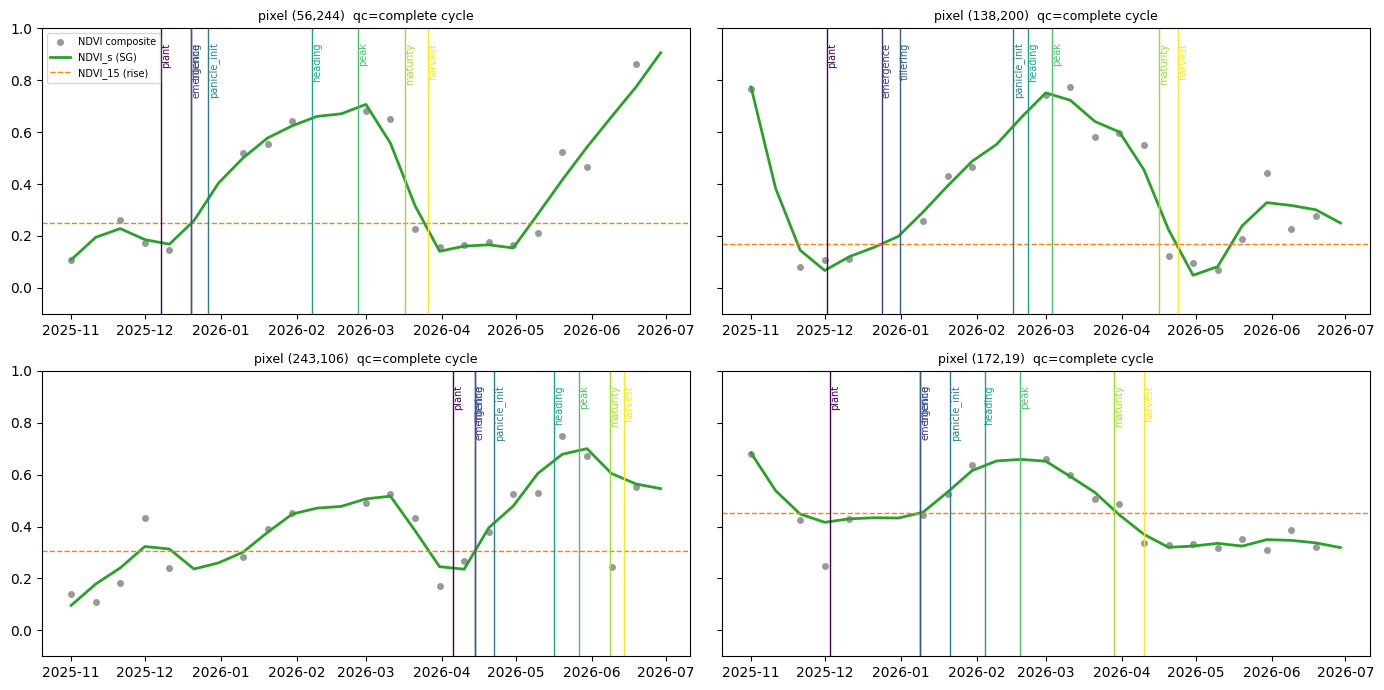

In [ ]:
def plot_pixel(ds, pheno, iy, ix, ax):
    X = ds['NDVI'].values[:, iy, ix]
    t = pd.DatetimeIndex(ds['time'].values)
    S, F = ph.smooth_series(X, PHENO_CFG)
    ax.plot(t, X, 'o', ms=4, color='0.6', label='NDVI composite')
    ax.plot(t, S, '-', color='tab:green', lw=2, label='NDVI_s (SG)')
    p = pheno.isel(y=iy, x=ix)
    if np.isfinite(p['ndvi15']):
        ax.axhline(float(p['ndvi15']), ls='--', color='tab:orange', lw=1, label='NDVI_15 (rise)')
    for b, col in zip(ph.DATE_BANDS, plt.cm.viridis(np.linspace(0, 1, len(ph.DATE_BANDS)))):
        v = float(p[b])
        if np.isfinite(v):
            ax.axvline(ph.from_epoch_days(v)[0], color=col, lw=1)
            ax.text(ph.from_epoch_days(v)[0], 0.95, b, rotation=90, fontsize=7,
                    va='top', color=col, transform=ax.get_xaxis_transform())
    ax.set_ylim(-0.1, 1); ax.set_title(f'pixel ({iy},{ix})  qc={ph.QC_DESCRIPTION.get(int(p["qc"]), "nodata") if np.isfinite(p["qc"]) else "nodata"}', fontsize=9)

rice_px = np.argwhere(qc == 0)
fig, axs = plt.subplots(2, 2, figsize=(14, 7), sharey=True)
for ax, (iy, ix) in zip(axs.ravel(), rice_px[np.random.default_rng(0).choice(len(rice_px), 4, replace=False)]):
    plot_pixel(ds_test, pheno_test, iy, ix, ax)
axs[0, 0].legend(fontsize=7); plt.tight_layout(); plt.show()

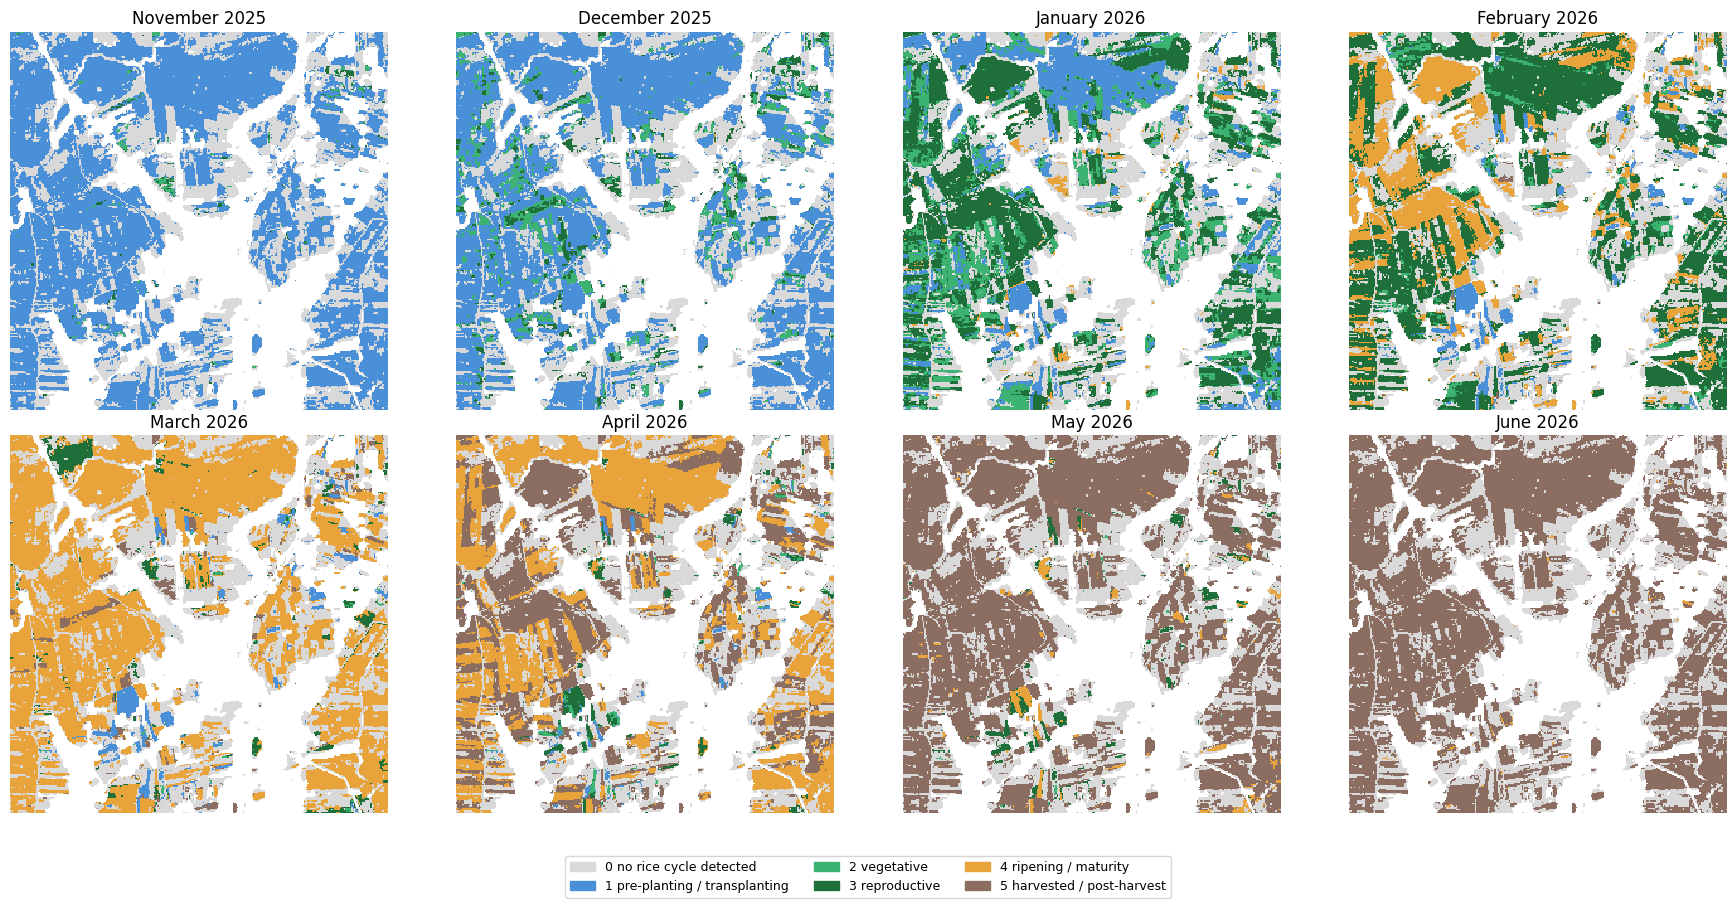

In [ ]:
# 0 no rice | 1 pre-planting/transplanting | 2 vegetative | 3 reproductive | 4 ripening/maturity | 5 harvested
STAGE_COLORS = ['#d9d9d9', '#4a90d9', '#3cb371', '#1f6f3a', '#e8a33a', '#8c6d62']
def plot_stage(stage_da, ax):
    a = stage_da.values.astype(float); a[a < 0] = np.nan
    ax.imshow(a, cmap=ListedColormap(STAGE_COLORS), vmin=-0.5, vmax=len(STAGE_COLORS)-0.5, interpolation='nearest')
    ax.set_title(pd.Timestamp(stage_da.attrs['as_of']).strftime('%B %Y')); ax.axis('off')

months_test = MONTHS or ph.season_months(pheno_test)
ncol = 4; nrow = int(np.ceil(len(months_test) / ncol))
fig, axs = plt.subplots(nrow, ncol, figsize=(4.5 * ncol, 4.5 * nrow))
for ax in np.ravel(axs)[len(months_test):]:
    ax.axis('off')
for ax, m in zip(np.ravel(axs), months_test):
    plot_stage(ph.classify_stage_month(pheno_test, m, STAGE_METHOD), ax)
fig.legend(handles=[Patch(color=c, label=f'{k} {v}') for (k, v), c in zip(ph.STAGE_CLASSES.items(), STAGE_COLORS)],
           loc='lower center', ncol=3, fontsize=9)
plt.tight_layout(rect=(0, 0.08, 1, 1)); plt.show()

## GCS Helpers

In [ ]:
def _gcs_blob_exists(bucket_name, blob_path):
    return gcs_client.bucket(bucket_name).blob(blob_path).exists()

def _upload(local, gcs_path, bucket=GCS_BUCKET):
    gcs_client.bucket(bucket).blob(gcs_path).upload_from_filename(local)
    return f'gs://{bucket}/{gcs_path}'

def _prov(prov_name):
    return str(prov_name).replace(" ", "_")

def month_blob_path(prov_name, month):                 # month = 'YYYY-MM'
    return f'{GCS_PREFIX}/{COG_LABEL}_{_prov(prov_name)}_{month.replace("-", "")}.tiff'

def pheno_blob_path(prov_name):                         # optional QA file
    return f'{GCS_PREFIX}/qa/{COG_LABEL}_{_prov(prov_name)}_phenology_dates.tiff'

def months_for(prov_name):
    # months to generate for a province (MONTHS, or its season window)
    if MONTHS:
        return list(MONTHS)
    sub = gdf.loc[gdf[PROV_COL] == prov_name]
    pm = int(sub.iloc[0][PLANT_MO_COL]) if pd.notna(sub.iloc[0][PLANT_MO_COL]) else PLANTING_MONTH_FALLBACK
    s, e = dp.season_window(pm, YEAR)
    return [str(p) for p in pd.period_range(s, e, freq='M')]

def save_products_gcs(pheno, prov_name, local_tmp_dir='/tmp/growth_stage'):
    os.makedirs(local_tmp_dir, exist_ok=True)
    uris = []
    for m in months_for(prov_name):                     # one single-band COG per month
        st = ph.classify_stage_month(pheno, m, STAGE_METHOD)
        if STAGE_MAJORITY_RADIUS:
            st = st.copy(data=ph.majority_filter(st.values, STAGE_MAJORITY_RADIUS))
        local = os.path.join(local_tmp_dir, os.path.basename(month_blob_path(prov_name, m)))
        ph.write_stage_cog(st, local)
        uris.append(_upload(local, month_blob_path(prov_name, m))); os.remove(local)
    if SAVE_PHENOLOGY_BANDS:
        local = os.path.join(local_tmp_dir, os.path.basename(pheno_blob_path(prov_name)))
        ph.write_cog(pheno, local, ref_year=YEAR)
        _upload(local, pheno_blob_path(prov_name)); os.remove(local)
    return uris

def all_months_exist(prov_name):
    return all(_gcs_blob_exists(GCS_BUCKET, month_blob_path(prov_name, m)) for m in months_for(prov_name))


## Batch Run

In [ ]:
def process_province_mpc(prov_name):
    sub  = gdf.loc[gdf[PROV_COL] == prov_name]
    bbox = tuple(sub.total_bounds)
    pm   = int(sub.iloc[0][PLANT_MO_COL]) if pd.notna(sub.iloc[0][PLANT_MO_COL]) else PLANTING_MONTH_FALLBACK
    # phenology runs per tile right after each tile cube is built -> only the
    # small 2-D products are kept and mosaicked (memory stays ~one tile cube)
    # geometry: tiles outside the province outline (open sea) are skipped
    # cache_dir: finished tiles are kept on Drive, so a failed/interrupted
    #            province resumes instead of restarting (empty it after
    #            changing PHENO_CFG or dp.* settings)
    pheno = dp.build_province_datacube_tiled(
        bbox, pm, YEAR, tile_deg=TILE_DEG, geometry=sub,
        cache_dir=os.path.join(TILE_CACHE_DIR, _prov(prov_name)),
        per_tile_fn=lambda ds: ph.run_phenology(ds, **PHENO_CFG))
    if pheno is None:
        return None
    pheno = ph.smooth_dates(pheno, DATE_MEDIAN_RADIUS)
    pheno = dp.clip_to_geometry(pheno, sub)
    pheno.attrs['province'] = prov_name
    gc.collect()
    return pheno

def batch_all(provinces, skip_existing=True, start_from=None):
    names = list(provinces)
    if start_from is not None:
        if start_from not in names:
            raise ValueError(f'{start_from!r} not in province list')
        names = names[names.index(start_from):]
        print(f'resuming from {start_from!r}')
    results = {'success': [], 'skipped': [], 'no_coverage': [], 'failed': []}
    for name in tqdm(names, desc='provinces', unit='prov'):
        if skip_existing and all_months_exist(name):
            results['skipped'].append(name); tqdm.write(f'  {name}: skipped (exists)'); continue
        t0 = time.time()
        try:
            pheno = process_province_mpc(name)
            if pheno is None:
                results['no_coverage'].append(name); tqdm.write(f'  {name}: no coverage'); continue
            uris = save_products_gcs(pheno, name)
            results['success'].append((name, uris[0].rsplit('/', 1)[0]))
            tqdm.write(f'  {name}: ok ({(time.time()-t0)/60:.1f} min) -> {len(uris)} monthly maps in {uris[0].rsplit("/", 1)[0]}')
            del pheno; gc.collect()
        except Exception as e:
            results['failed'].append((name, repr(e)))
            tqdm.write(f'  {name}: ERROR {e}')
            traceback.print_exc(); gc.collect()
    print(f"\nsucceeded {len(results['success'])} | skipped {len(results['skipped'])} "
          f"| no_coverage {len(results['no_coverage'])} | failed {len(results['failed'])}")
    for n, err in results['failed']:
        print('  FAILED', n, '::', err)
    return results

# normal run:
results = batch_all(provinces)
# resume after a disconnect, e.g.:
# results = batch_all(provinces, start_from='APAYAO')

provinces:   0%|          | 0/83 [00:00<?, ?prov/s]

  ABRA: skipped (exists)
  AGUSAN DEL NORTE: skipped (exists)
  AGUSAN DEL SUR: skipped (exists)
  AKLAN: skipped (exists)
  ALBAY: skipped (exists)
  ANTIQUE: skipped (exists)
  APAYAO: skipped (exists)
  AURORA: skipped (exists)
  BASILAN: skipped (exists)
  province split into 24 tile(s) of 0.1 deg


tiles:   0%|          | 0/24 [00:00<?, ?tile/s]

  BATAAN: ERROR 


Traceback (most recent call last):
  File "/tmp/ipykernel_7051/65641222.py", line 31, in batch_all
    pheno = process_province_mpc(name)
  File "/tmp/ipykernel_7051/65641222.py", line 7, in process_province_mpc
    pheno = dp.build_province_datacube_tiled(
        bbox, pm, YEAR, tile_deg=TILE_DEG,
        per_tile_fn=lambda ds: ph.run_phenology(ds, **PHENO_CFG))
  File "/content/drive/MyDrive/AGRI/Crop_Growth/notebooks/apps/data_processing.py", line 389, in build_province_datacube_tiled
    ds_t = build_province_datacube(tb, planting_month, year,
                                   apply_cropland_mask=apply_cropland_mask)
  File "/content/drive/MyDrive/AGRI/Crop_Growth/notebooks/apps/data_processing.py", line 295, in build_province_datacube
    scenes = load_s2_ndvi_stack(bbox, start, end)
  File "/content/drive/MyDrive/AGRI/Crop_Growth/notebooks/apps/data_processing.py", line 185, in load_s2_ndvi_stack
    ds = odc.stac.load(
        items, bands=["B04", "B08", "SCL"], bbox=list(bbox

...

  phenology: 0/0 crop pixels with a rice cycle (0 complete, 0 past peak, 0 pre-peak)
  phenology: 0/0 crop pixels with a rice cycle (0 complete, 0 past peak, 0 pre-peak)
  phenology: 0/0 crop pixels with a rice cycle (0 complete, 0 past peak, 0 pre-peak)
  phenology: 0/0 crop pixels with a rice cycle (0 complete, 0 past peak, 0 pre-peak)
  phenology: 0/0 crop pixels with a rice cycle (0 complete, 0 past peak, 0 pre-peak)
  phenology: 5/122 crop pixels with a rice cycle (5 complete, 0 past peak, 0 pre-peak)
  phenology: 97771/220230 crop pixels with a rice cycle (97728 complete, 0 past peak, 43 pre-peak)
  phenology: 39340/55743 crop pixels with a rice cycle (39321 complete, 0 past peak, 19 pre-peak)
  phenology: 12/469 crop pixels with a rice cycle (12 complete, 0 past peak, 0 pre-peak)
  phenology: 4/29 crop pixels with a rice cycle (4 complete, 0 past peak, 0 pre-peak)
  phenology: 7/266 crop pixels with a rice cycle (7 complete, 0 past peak, 0 pre-peak)
  phenology: 79/821 crop pixe

Traceback (most recent call last):
  File "/tmp/ipykernel_7051/65641222.py", line 31, in batch_all
    pheno = process_province_mpc(name)
  File "/tmp/ipykernel_7051/65641222.py", line 7, in process_province_mpc
    pheno = dp.build_province_datacube_tiled(
        bbox, pm, YEAR, tile_deg=TILE_DEG,
        per_tile_fn=lambda ds: ph.run_phenology(ds, **PHENO_CFG))
  File "/content/drive/MyDrive/AGRI/Crop_Growth/notebooks/apps/data_processing.py", line 389, in build_province_datacube_tiled
    ds_t = build_province_datacube(tb, planting_month, year,
                                   apply_cropland_mask=apply_cropland_mask)
  File "/content/drive/MyDrive/AGRI/Crop_Growth/notebooks/apps/data_processing.py", line 304, in build_province_datacube
    mask = cropland_mask_on_grid(cube.isel(time=0, drop=True))
  File "/content/drive/MyDrive/AGRI/Crop_Growth/notebooks/apps/data_processing.py", line 270, in cropland_mask_on_grid
    raise RuntimeError(
        f"ESA WorldCover returned no items

  province split into 21 tile(s) of 0.1 deg


tiles:   0%|          | 0/21 [00:00<?, ?tile/s]

  phenology: 1/15 crop pixels with a rice cycle (1 complete, 0 past peak, 0 pre-peak)
  phenology: 0/2 crop pixels with a rice cycle (0 complete, 0 past peak, 0 pre-peak)
  phenology: 263/1505 crop pixels with a rice cycle (262 complete, 0 past peak, 1 pre-peak)
  phenology: 4615/10864 crop pixels with a rice cycle (4504 complete, 0 past peak, 111 pre-peak)
  phenology: 171/1726 crop pixels with a rice cycle (171 complete, 0 past peak, 0 pre-peak)
  phenology: 6/94 crop pixels with a rice cycle (6 complete, 0 past peak, 0 pre-peak)


In [ ]:
rows = ([{'province': n, 'status': 'success', 'uri': u} for n, u in results['success']]
        + [{'province': n, 'status': 'skipped'} for n in results['skipped']]
        + [{'province': n, 'status': 'no_coverage'} for n in results['no_coverage']]
        + [{'province': n, 'status': 'failed', 'error': e} for n, e in results['failed']])
res = pd.DataFrame(rows).sort_values('province')
res.to_csv('/tmp/batch_summary_growth_stage.csv', index=False)
print(res['status'].value_counts())
res

## Extra stage maps later (no reprocessing)
The stage map is a pure function of the date bands. You can read a phenology COG back and classify any date:

In [ ]:
import rioxarray
def stage_from_cog(uri_or_path, as_of, ref_year=YEAR):
    da = rioxarray.open_rasterio(uri_or_path, masked=True)
    names = list(da.attrs.get('long_name', [])) or ph.DATE_BANDS + ['season_length','ndvi_min','ndvi_max','ndvi15','qc','n_obs','max_gap_days']
    ds = da.assign_coords(band=names).to_dataset('band')
    ref = ph.to_epoch_days(f'{ref_year}-01-01')[0] - 1
    for b in ph.DATE_BANDS:
        ds[b] = ds[b] + ref                      # DOY -> epoch days
    return ph.classify_stage(ds, as_of)

# st = stage_from_cog('gs://leads-agri/products/growth_stage/2026/dry/dry2026_NUEVA_ECIJA_phenology.tiff', '2026-02-01')